In [1]:
import pandas as pd, numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score

DATA = r"D:\Mortgage-Credit-Risk-Analytics\Data"
PERF_PATH = DATA + r"\processed\master_monthly_performance_clean.parquet"
OG_PATH   = DATA + r"\processed\master_origination_clean.parquet"
HPI_PATH  = DATA + r"\raw\hpi_at_state.xlsx"

DEFAULT_ZB = {2, 3, 9}          # terminal-default zero-balance codes

DISCOUNT_LGD   = False               # False -> nominal (accounting) LGD, matches your current field


In [2]:
NEED = ["loan_seq_no", "zero_balance_code", "zero_balance_effective_date",
        "current_actual_upb", "zero_balance_removal_upb", "actual_loss_calculation",
        "net_sale_proceeds", "mi_recoveries", "non_mi_recoveries",
        "total_expenses", "delinquent_accrued_interest",
        "current_interest_rate", "loan_age", "origination_year", "modification_flag"]

pf = pq.ParquetFile(PERF_PATH)
have = set(pf.schema_arrow.names)
need = [c for c in NEED if c in have]
missing = [c for c in NEED if c not in have]
if missing:
    print("NOTE: not in perf schema, will be treated as NaN:", missing)

parts = []
for rg in range(pf.num_row_groups):
    ch = pf.read_row_group(rg, columns=need).to_pandas()
    zb = pd.to_numeric(ch["zero_balance_code"], errors="coerce")
    ch = ch[zb.isin(DEFAULT_ZB)]
    if not ch.empty:
        parts.append(ch)

disp = pd.concat(parts, ignore_index=True)
for c in missing:
    disp[c] = np.nan
# one terminal record per loan (latest effective date)
disp = disp.sort_values("zero_balance_effective_date").groupby("loan_seq_no", as_index=False).last()
print("defaulted/resolved loans:", len(disp))
print("by vintage:\n", disp["origination_year"].value_counts().sort_index().to_string())

defaulted/resolved loans: 17779
by vintage:
 origination_year
2000     644
2001     591
2002     647
2003     698
2004    1453
2005    2690
2006    3834
2007    4261
2008    2012
2009     492
2010     457


actual_loss_calculation sample stats:
  min: -245,166  median: 62,854  max: 597,949
  share negative: 3.0%  share positive: 89.0%
-> kept sign (losses already positive)

loans after dropping missing loss: 16,435

LGD distribution:
count    16435.000
mean         0.491
std          0.303
min          0.000
25%          0.251
50%          0.486
75%          0.723
max          1.000

share with zero/near-zero loss : 3.7%
mean LGD (all)                 : 0.491
mean LGD | loss>0              : 0.510


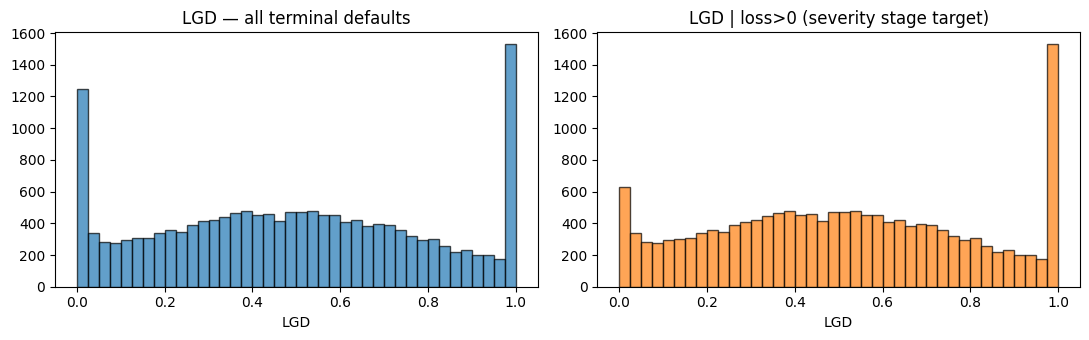

In [3]:
# BUILD THE LGD TARGET

num = lambda s: pd.to_numeric(disp[s], errors="coerce")

# EAD at default
disp["ead_d"] = num("zero_balance_removal_upb").fillna(num("current_actual_upb"))
disp = disp[disp["ead_d"] > 0].copy()

# used Freddie's pre-netted loss field directly
# sign check: Freddie stores losses as NEGATIVE (sale proceeds > balance = gain)
raw_loss = num("actual_loss_calculation")
print("actual_loss_calculation sample stats:")
print(f"  min: {raw_loss.min():,.0f}  median: {raw_loss.median():,.0f}  max: {raw_loss.max():,.0f}")
print(f"  share negative: {(raw_loss < 0).mean():.1%}  share positive: {(raw_loss > 0).mean():.1%}")

# (a negative actual_loss = Freddie LOST money = our loss)
if (raw_loss < 0).mean() > (raw_loss > 0).mean():
    disp["loss_nom"] = -raw_loss
    print("-> flipped sign (losses were negative)")
else:
    disp["loss_nom"] = raw_loss
    print("-> kept sign (losses already positive)")

# drop the 7.5% with missing loss field
disp = disp.dropna(subset=["loss_nom"]).copy()
print(f"\nloans after dropping missing loss: {len(disp):,}")

# LGD
disp["lgd"]     = (disp["loss_nom"] / disp["ead_d"]).clip(0, 1)
disp["loss_pos"] = (disp["lgd"] > 1e-4).astype(int)

print(f"\nLGD distribution:")
print(disp["lgd"].describe().round(3).to_string())
print(f"\nshare with zero/near-zero loss : {1 - disp['loss_pos'].mean():.1%}")
print(f"mean LGD (all)                 : {disp['lgd'].mean():.3f}")
print(f"mean LGD | loss>0              : {disp.loc[disp.loss_pos==1,'lgd'].mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(disp["lgd"], bins=40, edgecolor="k", alpha=.7)
ax[0].set_title("LGD — all terminal defaults")
ax[1].hist(disp.loc[disp.loss_pos==1, "lgd"], bins=40,
           color="tab:orange", edgecolor="k", alpha=.7)
ax[1].set_title("LGD | loss>0 (severity stage target)")
for a in ax: a.set_xlabel("LGD")
plt.tight_layout(); plt.show()

In [4]:
# HPI
hpi = pd.read_excel(HPI_PATH, skiprows=5)[["Abbreviation", "Year", "HPI with 2000 base"]]
hpi.columns = ["state", "year", "hpi"]
hpi["year"] = pd.to_numeric(hpi["year"], errors="coerce")
hpi["hpi"]  = pd.to_numeric(hpi["hpi"],  errors="coerce")
hpi = hpi.dropna().astype({"year": int})

# origination fields
OG_KEEP = ["loan_seq_no","og_ltv","og_upb","og_int_rate","og_loan_term","prop_state",
           "cred_score","og_dti","og_cltv","mortgage_insurance_percent",
           "no_of_borrowers","unit_no","loan_purpose","occupancy_status","prop_type"]
og = pd.read_parquet(OG_PATH)
og = og[[c for c in OG_KEEP if c in og.columns]].copy()

d = disp.merge(og, on="loan_seq_no", how="left")
d["og_ltv"] = pd.to_numeric(d["og_ltv"], errors="coerce").where(lambda s: s <= 105)

# indexed LTV
d["disp_year"] = pd.to_numeric(
    d["zero_balance_effective_date"].astype("Int64").astype("float") // 100,
    errors="coerce")
d = d.merge(hpi.rename(columns={"year":"disp_year","hpi":"hpi_disp"}),
            left_on=["prop_state","disp_year"], right_on=["state","disp_year"],
            how="left").drop(columns="state")
d = d.merge(hpi.rename(columns={"year":"origination_year","hpi":"hpi_orig"}),
            left_on=["prop_state","origination_year"], right_on=["state","origination_year"],
            how="left").drop(columns="state")
hpi_growth = (d["hpi_disp"] / d["hpi_orig"] - 1).fillna(0)
d["indexed_ltv"] = (d["og_ltv"] / (1 + hpi_growth)).clip(10, 250)\
                    .fillna(d["og_ltv"]).fillna(d["og_ltv"].median())

# continuous drivers
d["underwater_depth"]  = (d["indexed_ltv"] - 100).clip(lower=0)
d["age_at_default"]    = pd.to_numeric(d["loan_age"], errors="coerce")
d["mi_pct"]            = pd.to_numeric(d["mortgage_insurance_percent"], errors="coerce").clip(0, 55)
d["fico"]              = pd.to_numeric(d["cred_score"], errors="coerce").where(lambda s: (s>=300)&(s<=850))
d["dti"]               = pd.to_numeric(d["og_dti"], errors="coerce").where(lambda s: (s>0)&(s<=65))
d["cltv"]              = pd.to_numeric(d["og_cltv"], errors="coerce").where(lambda s: s<=200)
d["nborrow"]           = pd.to_numeric(d["no_of_borrowers"], errors="coerce")
d["units"]             = pd.to_numeric(d["unit_no"], errors="coerce")
d["og_int_rate"]       = pd.to_numeric(d["og_int_rate"], errors="coerce")
d["expense_ratio"]     = (pd.to_numeric(d["total_expenses"], errors="coerce") /
                          pd.to_numeric(d["zero_balance_removal_upb"], errors="coerce")).clip(0, 1)

# three new pre-default features

# 1. HPI decline since origination
#    how far the market fell between origination and disposition
#    directly determines how underwater the borrower is at foreclosure
d["hpi_decline"] = (-hpi_growth).clip(lower=0)

# 2. Equity shortfall in dollar terms
#    LTV=120 on a $500k loan is much worse than LTV=120 on a $100k loan
#    scale by 100,000 in _SCALE so coefficients stay readable
d["equity_shortfall"] = ((d["indexed_ltv"] / 100 - 1) * d["ead_d"]).clip(lower=0)

# 3. Refi × LTV interaction
#    cash-out refi at high LTV = weakest recovery combination
#    borrower extracted equity AND now owes more than house is worth
d["ltv_x_refi"] = (d["indexed_ltv"] / 100) * \
                   (d["loan_purpose"].astype("string").str.strip().str.upper() != "P").astype(int)

CONT = ["indexed_ltv","underwater_depth","age_at_default","mi_pct","fico","dti","cltv",
        "nborrow","units","og_int_rate","expense_ratio",
        "hpi_decline","equity_shortfall","ltv_x_refi"]
for c in CONT:
    d[c] = d[c].fillna(d[c].median())

# prop_type: single binary flag (avoids near-perfect separation from 5-category dummies)
# SF = single family (baseline); everything else (CO=condo, MH=manufactured, PU=PUD) -> flag=1
d["not_sf"] = (d["prop_type"].astype("string").str.strip().str.upper()
                .replace({"99": "SF", "<NA>": "SF"})   # recode rare/sentinel -> baseline
                != "SF").astype(int)
print("prop_type distribution (raw):")
print(d["prop_type"].value_counts(dropna=False).to_string())
print("not_sf rate:", d["not_sf"].mean().round(3))

# categoricals: purpose, occupancy
cat_dummy_cols = []
for canon, raw in [("purpose","loan_purpose"), ("occupancy","occupancy_status")]:
    dum = pd.get_dummies(d[raw].astype("string").fillna("NA"),
                         prefix=canon, drop_first=True).astype(int)
    d = pd.concat([d, dum], axis=1)
    cat_dummy_cols += list(dum.columns)

# judicial state flag
JUDICIAL = {"CT","DE","FL","HI","IL","IN","IA","KS","KY","LA","ME","NE","NJ","NM",
            "NY","ND","OH","PA","SC","SD","VT","WI"}
d["judicial"] = d["prop_state"].isin(JUDICIAL).astype(int)

# DRIVERS: CONT + not_sf + judicial + categoricals
DRIVERS = CONT + ["not_sf", "judicial"] + cat_dummy_cols
d = d.dropna(subset=["lgd"])

print(f"\n{len(DRIVERS)} drivers:", DRIVERS)
print("modelling frame:", d.shape)
print("null check:", d[DRIVERS].isna().sum().sum(), "nulls in driver block")

prop_type distribution (raw):
prop_type
SF    12398
PU     2132
CO     1582
MH      309
CP       13
99        1
not_sf rate: 0.246

20 drivers: ['indexed_ltv', 'underwater_depth', 'age_at_default', 'mi_pct', 'fico', 'dti', 'cltv', 'nborrow', 'units', 'og_int_rate', 'expense_ratio', 'hpi_decline', 'equity_shortfall', 'ltv_x_refi', 'not_sf', 'judicial', 'purpose_N', 'purpose_P', 'occupancy_P', 'occupancy_S']
modelling frame: (16435, 55)
null check: 0 nulls in driver block


#### Two-stage LGD model + out-of-time validation

Fit on pre-crisis default cohorts (`origination_year ≤ 2005`), test on crisis cohorts (`≥ 2006`).
That's the honest test for a regulatory parameter: does severity estimated in benign times hold when
the collateral market breaks?

- **Stage 1:** logistic `P(loss>0)`
- **Stage 2:** fractional-response logit of LGD on `{loss>0}` (quasi-binomial GLM, bounded [0,1])
- **Combined:** `E[LGD] = P(loss>0) · E[LGD|loss>0]`

In [5]:
_SCALE = {"indexed_ltv":100.0, "underwater_depth":100.0, "age_at_default":12.0,
          "mi_pct":100.0, "fico":100.0, "dti":100.0, "cltv":100.0,
          "equity_shortfall": 100000.0}
def design(frame):
    X = frame[DRIVERS].copy()
    for col, s in _SCALE.items():
        if col in X.columns: X[col] = X[col] / s
    return sm.add_constant(X, has_constant="add")

train = d[d["origination_year"] <= 2005]
test  = d[d["origination_year"] >= 2006]
print(f"train defaults: {len(train):,} | test defaults: {len(test):,}")

Xtr, Xte = design(train), design(test)

# Stage 1: probability of positive loss
s1 = sm.GLM(train["loss_pos"], Xtr, family=sm.families.Binomial()).fit()

# Stage 2: fractional-response logit on the loss>0 subset
pos = train[train["loss_pos"] == 1]
s2 = sm.GLM(pos["lgd"], design(pos), family=sm.families.Binomial()).fit()

def predict_lgd(frame):
    Xd = design(frame)
    p_pos = s1.predict(Xd)
    sev   = s2.predict(Xd)
    return (p_pos * sev).clip(0, 1)

test = test.copy();  test["lgd_hat"] = predict_lgd(test)
train = train.copy(); train["lgd_hat"] = predict_lgd(train)

print("\n Stage 1 (P loss>0) coefficients ")
print(s1.params.round(3).to_string())
print("\n Stage 2 (severity | loss>0) coefficients")
print(s2.params.round(3).to_string())
print("\n(positive indexed_ltv & underwater & judicial coeffs = model behaves as theory expects)")

train defaults: 6,289 | test defaults: 10,146

 Stage 1 (P loss>0) coefficients 
const              -2.427
indexed_ltv         4.879
underwater_depth    0.318
age_at_default      0.113
mi_pct             -5.367
fico               -0.098
dti                 0.033
cltv               -0.215
nborrow            -0.091
units               1.706
og_int_rate         0.015
expense_ratio       4.318
hpi_decline         2.873
equity_shortfall    2.183
ltv_x_refi          0.498
not_sf             -0.404
judicial            0.291
purpose_N          -0.192
purpose_P           0.117
occupancy_P        -0.510
occupancy_S        -0.432

 Stage 2 (severity | loss>0) coefficients
const              -2.809
indexed_ltv         4.163
underwater_depth   -0.527
age_at_default      0.034
mi_pct             -3.606
fico               -0.129
dti                -0.237
cltv               -0.129
nborrow            -0.262
units               0.244
og_int_rate         0.207
expense_ratio       4.659
hpi_decline       

out-of-time performance:
train (<=2005)    MAE 0.195 | RMSE 0.243 | mean actual 0.450 | mean pred 0.450 | bias -0.000
test  (>=2006)    MAE 0.171 | RMSE 0.214 | mean actual 0.517 | mean pred 0.509 | bias -0.008

Stage-1 discrimination (AUC on loss>0, diagnostic only): 0.816

calibration (test, by predicted decile):
                                pred  actual     n
bucket                                            
(0.016399999999999998, 0.259]  0.194   0.185  1015
(0.259, 0.339]                 0.301   0.306  1015
(0.339, 0.4]                   0.370   0.366  1014
(0.4, 0.455]                   0.429   0.430  1015
(0.455, 0.506]                 0.480   0.503  1014
(0.506, 0.558]                 0.532   0.546  1015
(0.558, 0.612]                 0.585   0.605  1014
(0.612, 0.677]                 0.645   0.660  1015
(0.677, 0.763]                 0.718   0.731  1014
(0.763, 0.994]                 0.838   0.838  1015


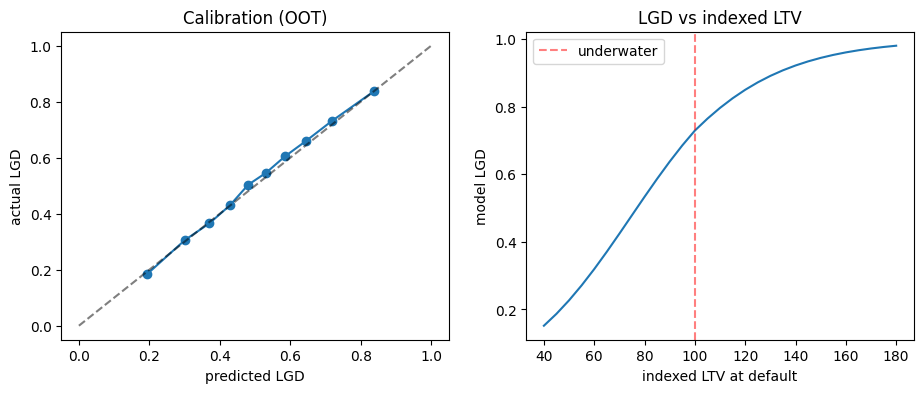

In [6]:
# LGD-appropriate validation (NOT auc for the LGD number)
def report(y, yhat, label):
    mae = mean_absolute_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    bias = yhat.mean() - y.mean()
    print(f"{label:16s}  MAE {mae:.3f} | RMSE {rmse:.3f} | mean actual {y.mean():.3f} "
          f"| mean pred {yhat.mean():.3f} | bias {bias:+.3f}")

print("out-of-time performance:")
report(train["lgd"], train["lgd_hat"], "train (<=2005)")
report(test["lgd"],  test["lgd_hat"],  "test  (>=2006)")
print("\nStage-1 discrimination (AUC on loss>0, diagnostic only):",
      round(roc_auc_score(test["loss_pos"], s1.predict(design(test))), 3))

# calibration by predicted decile (the chart a validator asks for)
tt = test.copy()
tt["bucket"] = pd.qcut(tt["lgd_hat"], 10, duplicates="drop")
cal = tt.groupby("bucket", observed=True).agg(pred=("lgd_hat","mean"),
                                              actual=("lgd","mean"), n=("lgd","size"))
print("\ncalibration (test, by predicted decile):")
print(cal.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(cal["pred"], cal["actual"], "o-"); ax[0].plot([0,1],[0,1],"k--",alpha=.5)
ax[0].set_xlabel("predicted LGD"); ax[0].set_ylabel("actual LGD"); ax[0].set_title("Calibration (OOT)")

grid = pd.DataFrame({"indexed_ltv": np.arange(40, 181, 5)})
for c in DRIVERS:
    if c not in grid.columns:
        grid[c] = train[c].median()          # hold every other driver at its median
grid["underwater_depth"] = (grid["indexed_ltv"] - 100).clip(lower=0)   # keep it consistent with LTV
grid["lgd_hat"] = predict_lgd(grid)
ax[1].plot(grid["indexed_ltv"], grid["lgd_hat"])
ax[1].axvline(100, color="r", ls="--", alpha=.5, label="underwater")
ax[1].set_xlabel("indexed LTV at default"); ax[1].set_ylabel("model LGD")
ax[1].set_title("LGD vs indexed LTV"); ax[1].legend()

STAGE 1 — P(loss > 0)  [CLASSIFIER]

  TRAIN  |  n=6,289  |  event rate=93.7%
    AUC    : 0.828   (want > 0.65 for LGD stage 1)
    KS     : 0.528   (want > 0.20)
    Brier  : 0.0522  (lower = better; naive=0.0589)
    Acc    : 0.937  |  Precision: 0.938  |  Recall: 0.998  (@ 0.5 threshold)

  TEST   |  n=10,146  |  event rate=97.8%
    AUC    : 0.816   (want > 0.65 for LGD stage 1)
    KS     : 0.491   (want > 0.20)
    Brier  : 0.0202  (lower = better; naive=0.0213)
    Acc    : 0.978  |  Precision: 0.978  |  Recall: 1.000  (@ 0.5 threshold)


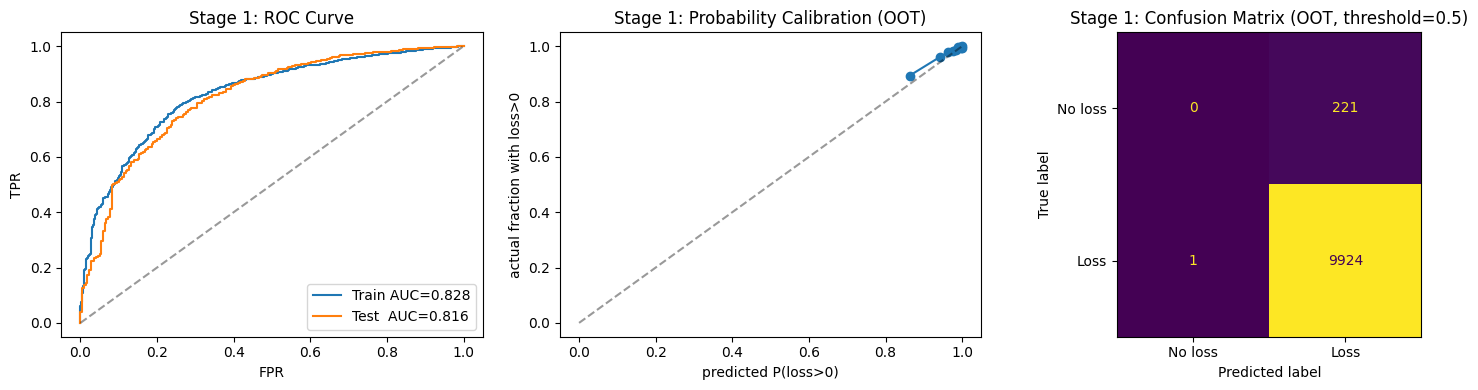


Stage 1 calibration by decile (OOT):
                   pred  actual     n
bucket                               
(0.4248, 0.9224]  0.863   0.894  1015
(0.9224, 0.9551]  0.941   0.961  1015
(0.9551, 0.9708]  0.964   0.979  1014
(0.9708, 0.9805]  0.976   0.983  1015
(0.9805, 0.9873]  0.984   0.986  1014
(0.9873, 0.9921]  0.990   0.996  1015
(0.9921, 0.9959]  0.994   0.996  1014
(0.9959, 0.9987]  0.997   0.993  1015
(0.9987, 0.9997]  0.999   0.995  1014
(0.9997, 1.0]     1.000   0.999  1015

STAGE 2: E(LGD | loss > 0)  [SEVERITY REGRESSION]

  TRAIN  |  n=5,894  |  mean actual LGD=0.480
    MAE    : 0.193   (naive mean-pred MAE = 0.265)
    RMSE   : 0.239
    R²     : 0.410   (how much severity variance is explained)
    Bias   : -0.0000 (+ = overpredicts, - = underpredicts)

  TEST   |  n=9,925  |  mean actual LGD=0.528
    MAE    : 0.169   (naive mean-pred MAE = 0.235)
    RMSE   : 0.211
    R²     : 0.434   (how much severity variance is explained)
    Bias   : -0.0043 (+ = overpredic

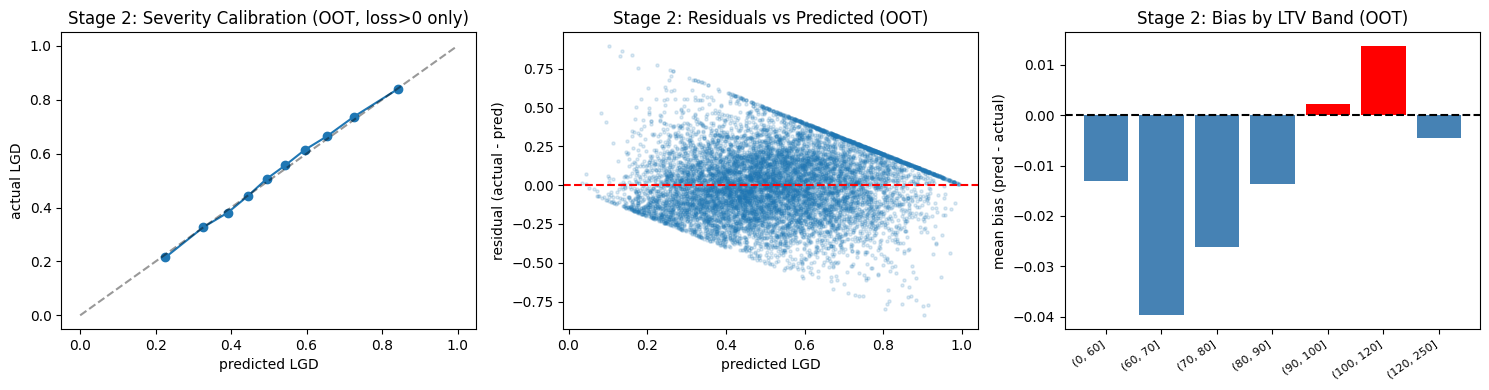


Stage 2 calibration by decile (OOT):
                  pred  actual    n
bucket                             
(0.0331, 0.287]  0.226   0.215  993
(0.287, 0.362]   0.326   0.327  992
(0.362, 0.419]   0.391   0.381  993
(0.419, 0.47]    0.445   0.444  992
(0.47, 0.518]    0.494   0.506  993
(0.518, 0.569]   0.543   0.557  992
(0.569, 0.621]   0.595   0.614  992
(0.621, 0.686]   0.653   0.664  993
(0.686, 0.769]   0.725   0.737  992
(0.769, 0.994]   0.842   0.840  993

Stage 2 bias by LTV band (OOT):
             bias     n
ltv_band               
(0, 60]    -0.013   338
(60, 70]   -0.040   409
(70, 80]   -0.026  1072
(80, 90]   -0.014  1685
(90, 100]   0.002  1934
(100, 120]  0.014  2499
(120, 250] -0.004  1988


In [7]:
# STAGE-LEVEL DIAGNOSTICS
# Stage 1: P(loss > 0), classifier metrics
# Stage 2: E(LGD | loss > 0), regression metrics

from sklearn.metrics import (roc_auc_score, roc_curve,
                             brier_score_loss, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

print("=" * 60)
print("STAGE 1 — P(loss > 0)  [CLASSIFIER]")
print("=" * 60)

# predictions
s1_prob_train = s1.predict(design(train))
s1_prob_test  = s1.predict(design(test))
s1_pred_train = (s1_prob_train >= 0.5).astype(int)
s1_pred_test  = (s1_prob_test  >= 0.5).astype(int)

for label, y_true, y_prob, y_pred in [
    ("TRAIN", train["loss_pos"], s1_prob_train, s1_pred_train),
    ("TEST ",  test["loss_pos"],  s1_prob_test,  s1_pred_test)
]:
    auc   = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    # KS statistic
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = (tpr - fpr).max()

    # accuracy, precision, recall at 0.5 threshold
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, cm[0,0])
    acc  = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    rec  = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    print(f"\n  {label}  |  n={len(y_true):,}  |  event rate={y_true.mean():.1%}")
    print(f"    AUC    : {auc:.3f}   (want > 0.65 for LGD stage 1)")
    print(f"    KS     : {ks:.3f}   (want > 0.20)")
    print(f"    Brier  : {brier:.4f}  (lower = better; naive={y_true.mean()*(1-y_true.mean()):.4f})")
    print(f"    Acc    : {acc:.3f}  |  Precision: {prec:.3f}  |  Recall: {rec:.3f}  (@ 0.5 threshold)")

# Stage 1 plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC curve
fpr_tr, tpr_tr, _ = roc_curve(train["loss_pos"], s1_prob_train)
fpr_te, tpr_te, _ = roc_curve(test["loss_pos"],  s1_prob_test)
axes[0].plot(fpr_tr, tpr_tr, label=f"Train AUC={roc_auc_score(train['loss_pos'], s1_prob_train):.3f}")
axes[0].plot(fpr_te, tpr_te, label=f"Test  AUC={roc_auc_score(test['loss_pos'],  s1_prob_test):.3f}")
axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("Stage 1: ROC Curve"); axes[0].legend()

# Calibration of Stage 1 probabilities
test_s1 = test.copy(); test_s1["s1_prob"] = s1_prob_test
test_s1["bucket"] = pd.qcut(test_s1["s1_prob"], 10, duplicates="drop")
s1_cal = test_s1.groupby("bucket", observed=True).agg(
    pred=("s1_prob","mean"), actual=("loss_pos","mean"), n=("loss_pos","size"))
axes[1].plot(s1_cal["pred"], s1_cal["actual"], "o-")
axes[1].plot([0,1],[0,1],"k--", alpha=0.4)
axes[1].set_xlabel("predicted P(loss>0)")
axes[1].set_ylabel("actual fraction with loss>0")
axes[1].set_title("Stage 1: Probability Calibration (OOT)")

# Confusion matrix (test)
ConfusionMatrixDisplay(confusion_matrix(test["loss_pos"], s1_pred_test),
                       display_labels=["No loss","Loss"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Stage 1: Confusion Matrix (OOT, threshold=0.5)")

plt.tight_layout(); plt.show()

print("\nStage 1 calibration by decile (OOT):")
print(s1_cal.round(3).to_string())

print("\n" + "=" * 60)
print("STAGE 2: E(LGD | loss > 0)  [SEVERITY REGRESSION]")
print("=" * 60)

# stage 2 operates only on loss>0 loans
test_pos  = test[test["loss_pos"]  == 1].copy()
train_pos = train[train["loss_pos"] == 1].copy()

s2_pred_train = s2.predict(design(train_pos)).clip(0, 1)
s2_pred_test  = s2.predict(design(test_pos)).clip(0, 1)

for label, y_true, y_pred in [
    ("TRAIN", train_pos["lgd"], s2_pred_train),
    ("TEST ", test_pos["lgd"],  s2_pred_test)
]:
    mae  = np.abs(y_true - y_pred).mean()
    rmse = np.sqrt(((y_true - y_pred)**2).mean())
    bias = y_pred.mean() - y_true.mean()
    r2   = 1 - ((y_true - y_pred)**2).sum() / ((y_true - y_true.mean())**2).sum()
    print(f"\n  {label}  |  n={len(y_true):,}  |  mean actual LGD={y_true.mean():.3f}")
    print(f"    MAE    : {mae:.3f}   (naive mean-pred MAE = {np.abs(y_true - y_true.mean()).mean():.3f})")
    print(f"    RMSE   : {rmse:.3f}")
    print(f"    R²     : {r2:.3f}   (how much severity variance is explained)")
    print(f"    Bias   : {bias:+.4f} (+ = overpredicts, - = underpredicts)")

# Stage 2 plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Calibration by decile
test_pos["s2_pred"] = s2_pred_test.values
test_pos["bucket"]  = pd.qcut(test_pos["s2_pred"], 10, duplicates="drop")
s2_cal = test_pos.groupby("bucket", observed=True).agg(
    pred=("s2_pred","mean"), actual=("lgd","mean"), n=("lgd","size"))
axes[0].plot(s2_cal["pred"], s2_cal["actual"], "o-")
axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
axes[0].set_xlabel("predicted LGD"); axes[0].set_ylabel("actual LGD")
axes[0].set_title("Stage 2: Severity Calibration (OOT, loss>0 only)")

# Residuals vs predicted
residuals = (test_pos["lgd"] - test_pos["s2_pred"]).values
axes[1].scatter(test_pos["s2_pred"], residuals, alpha=0.15, s=5)
axes[1].axhline(0, color="r", ls="--")
axes[1].set_xlabel("predicted LGD"); axes[1].set_ylabel("residual (actual - pred)")
axes[1].set_title("Stage 2: Residuals vs Predicted (OOT)")

# Residuals by indexed LTV band
test_pos["ltv_band"] = pd.cut(test_pos["indexed_ltv"], [0,60,70,80,90,100,120,250])
res_by_ltv = test_pos.groupby("ltv_band", observed=True).agg(
    bias=("lgd", lambda x: (test_pos.loc[x.index,"s2_pred"] - x).mean()),
    n=("lgd","size"))
axes[2].bar(range(len(res_by_ltv)), res_by_ltv["bias"], color=["red" if b>0 else "steelblue"
            for b in res_by_ltv["bias"]])
axes[2].axhline(0, color="k", ls="--")
axes[2].set_xticks(range(len(res_by_ltv)))
axes[2].set_xticklabels([str(b) for b in res_by_ltv.index], rotation=35, ha="right", fontsize=8)
axes[2].set_ylabel("mean bias (pred - actual)")
axes[2].set_title("Stage 2: Bias by LTV Band (OOT)")

plt.tight_layout(); plt.show()

print("\nStage 2 calibration by decile (OOT):")
print(s2_cal.round(3).to_string())

print("\nStage 2 bias by LTV band (OOT):")
print(res_by_ltv.round(3).to_string())

COMBINED MODEL — Full Two-Stage R²

  TRAIN (<=2005, all defaults)
    n          : 6,289
    mean actual: 0.450
    mean pred  : 0.450
    R²         : 0.431
    MAE        : 0.195
    RMSE       : 0.243
    Bias       : -0.0003

  TEST  (>=2006, all defaults)
    n          : 10,146
    mean actual: 0.517
    mean pred  : 0.509
    R²         : 0.446
    MAE        : 0.171
    RMSE       : 0.214
    Bias       : -0.0078

  Stage 2 only R² (loss>0 subset) — train: 0.405  test: 0.437
  Combined R²    (all defaults)   — train: 0.431  test: 0.446

  The combined number is the correct one to report.

  Stage 1 McFadden pseudo-R² (OOT): 0.136
  (diagnostic only: Stage 1 is near-degenerate at 97.8% event rate)


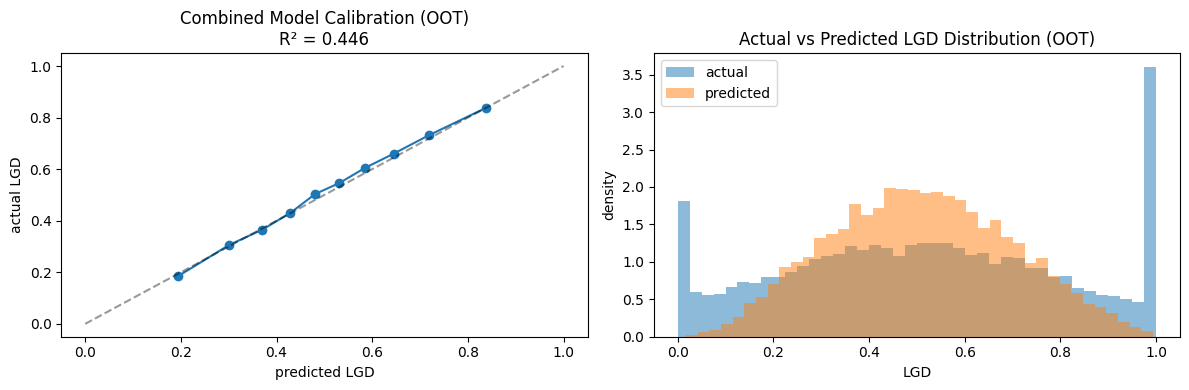


Full calibration table (combined, OOT):
                                pred  actual     n
bucket                                            
(0.016399999999999998, 0.259]  0.194   0.185  1015
(0.259, 0.339]                 0.301   0.306  1015
(0.339, 0.4]                   0.370   0.366  1014
(0.4, 0.455]                   0.429   0.430  1015
(0.455, 0.506]                 0.480   0.503  1014
(0.506, 0.558]                 0.532   0.546  1015
(0.558, 0.612]                 0.585   0.605  1014
(0.612, 0.677]                 0.645   0.660  1015
(0.677, 0.763]                 0.718   0.731  1014
(0.763, 0.994]                 0.838   0.838  1015


In [8]:
# COMBINED MODEL R²
# Stage 1 × Stage 2 evaluated on ALL defaulted loans (not just loss>0)
# This is what the model actually outputs


print("=" * 60)
print("COMBINED MODEL — Full Two-Stage R²")
print("=" * 60)

# combined predictions already computed: test["lgd_hat"], train["lgd_hat"]
# target: test["lgd"], train["lgd"]  (includes the zero-loss loans)

def combined_r2(y_true, y_pred, label):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    r2   = 1 - ss_res / ss_tot
    mae  = np.abs(y_true - y_pred).mean()
    rmse = np.sqrt(((y_true - y_pred)**2).mean())
    bias = y_pred.mean() - y_true.mean()
    print(f"\n  {label}")
    print(f"    n          : {len(y_true):,}")
    print(f"    mean actual: {y_true.mean():.3f}")
    print(f"    mean pred  : {y_pred.mean():.3f}")
    print(f"    R²         : {r2:.3f}")
    print(f"    MAE        : {mae:.3f}")
    print(f"    RMSE       : {rmse:.3f}")
    print(f"    Bias       : {bias:+.4f}")
    return r2

r2_train = combined_r2(train["lgd"], train["lgd_hat"], "TRAIN (<=2005, all defaults)")
r2_test  = combined_r2(test["lgd"],  test["lgd_hat"],  "TEST  (>=2006, all defaults)")

print(f"\n  Stage 2 only R² (loss>0 subset) — train: 0.405  test: 0.437")
print(f"  Combined R²    (all defaults)   — train: {r2_train:.3f}  test: {r2_test:.3f}")
print(f"\n  The combined number is the correct one to report.")

# pseudo-R² for Stage 1 (McFadden) for completeness
from scipy import stats
null_ll  = stats.bernoulli.logpmf(test["loss_pos"], test["loss_pos"].mean()).sum()
full_ll  = stats.bernoulli.logpmf(test["loss_pos"], s1.predict(design(test))).sum()
mcfadden = 1 - full_ll / null_ll
print(f"\n  Stage 1 McFadden pseudo-R² (OOT): {mcfadden:.3f}")
print(f"  (diagnostic only: Stage 1 is near-degenerate at 97.8% event rate)")

# visual: actual vs predicted on full test population
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# calibration on all defaults
tt = test.copy()
tt["bucket"] = pd.qcut(tt["lgd_hat"], 10, duplicates="drop")
cal_full = tt.groupby("bucket", observed=True).agg(
    pred=("lgd_hat","mean"), actual=("lgd","mean"), n=("lgd","size"))
ax[0].plot(cal_full["pred"], cal_full["actual"], "o-")
ax[0].plot([0,1],[0,1],"k--", alpha=0.4)
ax[0].set_xlabel("predicted LGD"); ax[0].set_ylabel("actual LGD")
ax[0].set_title(f"Combined Model Calibration (OOT)\nR² = {r2_test:.3f}")

# distribution of actual vs predicted
ax[1].hist(test["lgd"],     bins=40, alpha=0.5, label="actual",    density=True)
ax[1].hist(test["lgd_hat"], bins=40, alpha=0.5, label="predicted", density=True)
ax[1].set_xlabel("LGD"); ax[1].set_ylabel("density")
ax[1].set_title("Actual vs Predicted LGD Distribution (OOT)")
ax[1].legend()

plt.tight_layout(); plt.show()

print("\nFull calibration table (combined, OOT):")
print(cal_full.round(3).to_string())

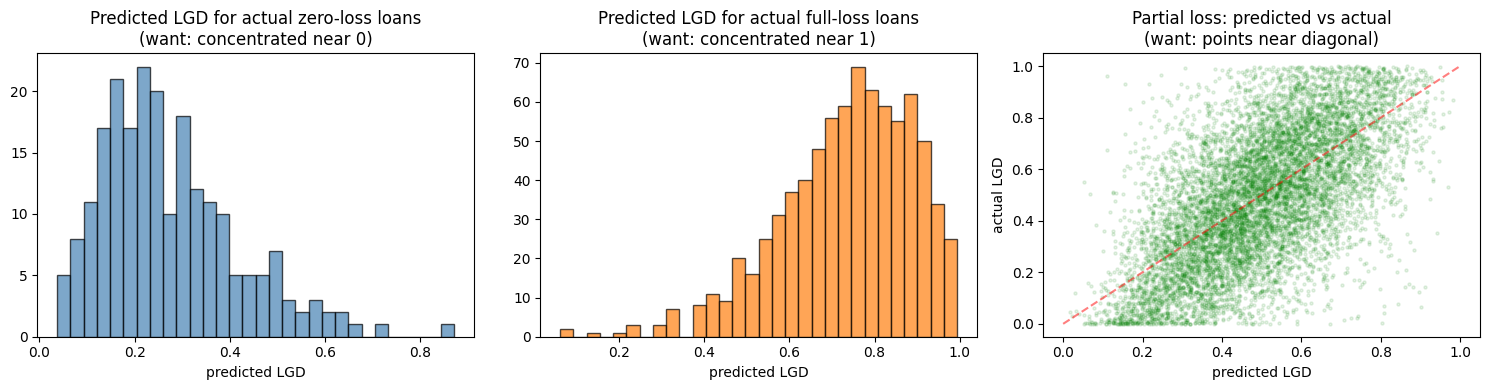

For actual zero-loss loans:
  mean predicted LGD : 0.273  (want near 0)
  % predicted < 0.20 : 35.6%

For actual full-loss loans:
  mean predicted LGD : 0.734  (want near 1)
  % predicted > 0.70 : 63.6%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. what does the model predict for zero-loss loans?
axes[0].hist(test.loc[test["lgd"]==0, "lgd_hat"], bins=30, 
             edgecolor="k", alpha=0.7, color="steelblue")
axes[0].set_title("Predicted LGD for actual zero-loss loans\n(want: concentrated near 0)")
axes[0].set_xlabel("predicted LGD")

# 2. what does the model predict for full-loss loans?
axes[1].hist(test.loc[test["lgd"]==1, "lgd_hat"], bins=30,
             edgecolor="k", alpha=0.7, color="tab:orange")
axes[1].set_title("Predicted LGD for actual full-loss loans\n(want: concentrated near 1)")
axes[1].set_xlabel("predicted LGD")

# 3. partial loss: predicted vs actual scatter
partial_test = test[(test["lgd"] > 1e-4) & (test["lgd"] < 1-1e-4)]
axes[2].scatter(partial_test["lgd_hat"], partial_test["lgd"], 
                alpha=0.1, s=5, color="green")
axes[2].plot([0,1],[0,1],"r--", alpha=0.5)
axes[2].set_xlabel("predicted LGD"); axes[2].set_ylabel("actual LGD")
axes[2].set_title("Partial loss: predicted vs actual\n(want: points near diagonal)")

plt.tight_layout()
plt.show()

# summary stats
print("For actual zero-loss loans:")
print(f"  mean predicted LGD : {test.loc[test['lgd']==0, 'lgd_hat'].mean():.3f}  (want near 0)")
print(f"  % predicted < 0.20 : {(test.loc[test['lgd']==0, 'lgd_hat'] < 0.20).mean():.1%}")

print("\nFor actual full-loss loans:")
print(f"  mean predicted LGD : {test.loc[test['lgd']==1, 'lgd_hat'].mean():.3f}  (want near 1)")
print(f"  % predicted > 0.70 : {(test.loc[test['lgd']==1, 'lgd_hat'] > 0.70).mean():.1%}")

### GBM cross-check

In [10]:
try:
    from sklearn.ensemble import HistGradientBoostingRegressor
    gbm = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05,
                                        max_iter=300, l2_regularization=1.0)
    gbm.fit(train[DRIVERS], train["lgd"])
    gpred = np.clip(gbm.predict(test[DRIVERS]), 0, 1)
    report(test["lgd"], pd.Series(gpred, index=test.index), "GBM (test)")
    print("-> compare to two-stage GLM above; GLM preferred for transparency + extrapolation.")
except Exception as e:
    print("GBM cross-check skipped:", e)

GBM (test)        MAE 0.171 | RMSE 0.214 | mean actual 0.517 | mean pred 0.523 | bias +0.006
-> compare to two-stage GLM above; GLM preferred for transparency + extrapolation.


In [11]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# build the test-side equivalent of `pos` (Stage 2 test subset)
pos_test = test[test["loss_pos"] == 1]

# design matrices for Stage 2 only (loss>0 subset), same features the GLM sees
Xtr_s2 = design(pos)[DRIVERS]
Xte_s2 = design(pos_test)[DRIVERS]
ytr_s2 = pos["lgd"]
yte_s2 = pos_test["lgd"]

gbm = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
gbm.fit(Xtr_s2, ytr_s2)

pred_gbm = gbm.predict(Xte_s2)
print("GBM  test R²  :", r2_score(yte_s2, pred_gbm))
print("GBM  test MAE :", mean_absolute_error(yte_s2, pred_gbm))
print("GBM  test RMSE:", mean_squared_error(yte_s2, pred_gbm) ** 0.5)
print("GBM  test bias:", (pred_gbm - yte_s2).mean())

GBM  test R²  : 0.4289366769218982
GBM  test MAE : 0.17014403633613373
GBM  test RMSE: 0.2117142370366246
GBM  test bias: 0.00527686593881399


#### Apply to the whole book + downturn

Score every loan's LGD from its **indexed LTV** (reuse `current_ltv_proxy` from your PD output if
present; otherwise fall back to origination LTV). The downturn number comes from the *same model*:
shock HPI down, indexed LTV rises, LGD rises — no separate crisis lookup needed.

In [12]:
# origination fields needed for scoring
OG_KEEP = ["loan_seq_no","og_ltv","og_upb","og_int_rate","prop_state",
           "cred_score","og_dti","og_cltv","mortgage_insurance_percent",
           "no_of_borrowers","unit_no","loan_purpose","occupancy_status","prop_type","origination_year"]
og_full = pd.read_parquet(OG_PATH)
og_full = og_full[[c for c in OG_KEEP if c in og_full.columns]].copy()

pd_df = pd.read_parquet("behavioural_pd_output.parquet")
book  = pd_df.merge(og_full, on="loan_seq_no", how="left")

# indexed_ltv: reuse current_ltv_proxy from PD output if available, else og_ltv
if "current_ltv_proxy" in book.columns:
    book["indexed_ltv"] = pd.to_numeric(book["current_ltv_proxy"], errors="coerce")
else:
    book["indexed_ltv"] = pd.to_numeric(book["og_ltv"], errors="coerce")
book["indexed_ltv"] = book["indexed_ltv"].clip(10, 250).fillna(book["indexed_ltv"].median())

# store training medians once so build_book_features always fills with the training distribution
TRAIN_MEDIANS = {c: d[c].median() for c in CONT}

# compute hpi_decline for the performing book
# obs_year = origination_year + 1 
tmp = og_full[["loan_seq_no", "prop_state", "origination_year"]].copy()
tmp["origination_year"] = pd.to_numeric(tmp["origination_year"], errors="coerce")
tmp["obs_year"] = tmp["origination_year"] + 1

# hpi at observation date
tmp = tmp.merge(hpi.rename(columns={"year":"obs_year", "hpi":"hpi_obs"}),
                left_on=["prop_state","obs_year"],
                right_on=["state","obs_year"], how="left").drop(columns="state")

# hpi at origination
tmp = tmp.merge(hpi.rename(columns={"year":"origination_year", "hpi":"hpi_at_orig"}),
                left_on=["prop_state","origination_year"],
                right_on=["state","origination_year"], how="left").drop(columns="state")

tmp["hpi_growth"] = (tmp["hpi_obs"] / tmp["hpi_at_orig"] - 1).fillna(0)
tmp["hpi_decline_book"] = (-tmp["hpi_growth"]).clip(lower=0)

book = book.merge(tmp[["loan_seq_no","hpi_decline_book"]], on="loan_seq_no", how="left")
book["hpi_decline_book"] = book["hpi_decline_book"].fillna(0)

def build_book_features(frame, hpi_shock=0.0):
    f = frame.copy()

    # HPI shock -> indexed LTV rises
    f["indexed_ltv"] = (f["indexed_ltv"] / (1 + hpi_shock)).clip(10, 250)

    # CONT features
    f["underwater_depth"] = (f["indexed_ltv"] - 100).clip(lower=0)
    f["mi_pct"]     = pd.to_numeric(f["mortgage_insurance_percent"], errors="coerce").clip(0, 55)
    f["fico"]       = pd.to_numeric(f["cred_score"],  errors="coerce").where(lambda s: (s>=300)&(s<=850))
    f["dti"]        = pd.to_numeric(f["og_dti"],      errors="coerce").where(lambda s: (s>0)&(s<=65))
    f["cltv"]       = pd.to_numeric(f["og_cltv"],     errors="coerce").where(lambda s: s<=200)
    f["nborrow"]    = pd.to_numeric(f["no_of_borrowers"], errors="coerce")
    f["units"]      = pd.to_numeric(f["unit_no"],     errors="coerce")
    f["og_int_rate"]= pd.to_numeric(f["og_int_rate"], errors="coerce")
    f["expense_ratio"] = TRAIN_MEDIANS["expense_ratio"]   # >>> ASSUMPTION

    if "loan_age" in f.columns:
        f["age_at_default"] = pd.to_numeric(f["loan_age"], errors="coerce")
    else:
        f["age_at_default"] = TRAIN_MEDIANS["age_at_default"]  # >>> ASSUMPTION

    # fill CONT nulls with training medians
    for c in CONT:
        if c in f.columns:
            f[c] = f[c].fillna(TRAIN_MEDIANS[c])
        else:
            f[c] = TRAIN_MEDIANS[c]

    # non-CONT features
    # hpi_decline: real computed value from book HPI
    f["hpi_decline"] = f["hpi_decline_book"].fillna(0)

    # equity_shortfall: computable from indexed_ltv + og_upb
    f["equity_shortfall"] = ((f["indexed_ltv"] / 100 - 1) *
                              pd.to_numeric(f["og_upb"], errors="coerce")
                              .fillna(0)).clip(lower=0)

    # ltv_x_refi: computable from indexed_ltv + loan_purpose
    f["ltv_x_refi"] = (f["indexed_ltv"] / 100) * \
                       (f["loan_purpose"].astype("string").str.strip().str.upper() != "P").astype(int)

    # prop_type flag
    if "prop_type" in f.columns:
        f["not_sf"] = (f["prop_type"].astype("string").str.strip().str.upper()
                        .replace({"99": "SF", "<NA>": "SF"}) != "SF").astype(int)
    else:
        f["not_sf"] = 0

    # categoricals
    for canon, raw in [("purpose","loan_purpose"), ("occupancy","occupancy_status")]:
        dum = pd.get_dummies(f[raw].astype("string").fillna("NA"),
                             prefix=canon, drop_first=True).astype(int)
        f = pd.concat([f, dum], axis=1)

    f["judicial"] = f["prop_state"].isin(JUDICIAL).astype(int)

    # align to exact training DRIVERS
    Xd = f.reindex(columns=DRIVERS, fill_value=0)
    return predict_lgd(Xd).values

book["LGD"]          = build_book_features(book, 0.00)

print(f"portfolio mean LGD (base)     : {book['LGD'].mean():.3f}")

portfolio mean LGD (base)     : 0.287


In [13]:
print("=== Workout assumptions applied to performing book ===")
print(f"  expense_ratio     (training median): {TRAIN_MEDIANS['expense_ratio']:.3f}")
print("  These represent through-the-cycle average workout conditions")
print("  from 17,374 resolved defaults, 2000-2010.")

=== Workout assumptions applied to performing book ===
  expense_ratio     (training median): 0.092
  These represent through-the-cycle average workout conditions
  from 17,374 resolved defaults, 2000-2010.


In [14]:
lgd_out = book[["loan_seq_no", "indexed_ltv", "LGD"]].copy()
lgd_out.to_parquet("lgd_model_output.parquet")
print("saved lgd_model_output.parquet:", lgd_out.shape)
print(lgd_out.head())

saved lgd_model_output.parquet: (471654, 3)
    loan_seq_no  indexed_ltv       LGD
0  F00Q10000049           61  0.451775
1  F00Q10000095           80  0.637407
2  F00Q10000106           95  0.248637
3  F00Q10000108           59  0.317057
4  F00Q10000184           74  0.507819
